# Calculus for Artificial Intelligence

Calculus is the mathematics of change. In artificial intelligence, almost every model is **trained** rather than programmed — we adjust millions of parameters to minimize a loss function that measures how wrong the model's predictions are. The tool that tells us which direction to adjust those parameters is the **gradient**, built from **derivatives** and **partial derivatives**. Without calculus, there is no gradient descent, no backpropagation, and no deep learning.

This notebook develops the calculus concepts essential for AI: derivatives, the chain rule, gradients, optimization, and the connection to neural network training. Each idea is explained with formulas and implemented in Python using NumPy, so you can see the mathematics in action.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")

---

## 1. Why Calculus Matters in AI

Training a machine learning model is an **optimization problem**: find the parameter values that minimize a **loss function** $L$. For a model with parameters $\theta_1, \theta_2, \ldots, \theta_n$, we seek:

$$\theta^* = \arg\min_{\theta} L(\theta)$$

For most AI models, $L$ is a complex, nonlinear function of millions of parameters with no closed-form solution. Instead, we use **iterative methods** — start with random parameters and repeatedly take small steps in the direction that decreases the loss. Calculus tells us which direction that is.

The **derivative** (or **gradient** in multiple dimensions) answers: *if I nudge a parameter slightly, does the loss go up or down, and by how much?* **Gradient descent** uses this information to update parameters:

$$\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)$$

where $\eta$ is the **learning rate** and $\nabla L$ is the gradient. **Backpropagation** — the algorithm that trains neural networks — is the chain rule of calculus applied systematically across layers. Every training run you have ever seen is calculus operating at scale.

---

## 2. Functions and the Idea of a Derivative

A **function** $f(x)$ maps an input $x$ to an output $y$. In AI, $f$ might be a loss function mapping parameter values to a scalar error, or an activation function mapping a neuron's weighted input to its output.

The **derivative** of $f$ with respect to $x$, written $f'(x)$ or $\frac{df}{dx}$, measures the **instantaneous rate of change** of $f$ at point $x$. Geometrically, it is the **slope of the tangent line** to the curve at that point.

The formal definition uses a limit:

$$f'(x) = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}$$

In words: nudge $x$ by a tiny amount $h$, measure how much $f$ changes, divide by $h$, and let $h$ approach zero. A positive derivative means $f$ increases as $x$ increases. A negative derivative means $f$ decreases as $x$ increases. A derivative of zero means $f$ is flat — potentially a minimum, maximum, or saddle point.

In [ ]:
def numerical_derivative(f, x, h=1e-7):
    """Approximate f'(x) using the limit definition."""
    return (f(x + h) - f(x - h)) / (2 * h)  # central difference (more accurate)

def f(x):
    return x ** 2  # f(x) = x^2, derivative should be 2x

x = 3.0
print(f"f(x) = x^2 at x = {x}")
print(f"Numerical derivative: {numerical_derivative(f, x):.6f}")
print(f"Analytical derivative 2x: {2 * x:.6f}")

---

## 3. Rules of Differentiation

Computing derivatives from the limit definition every time is impractical. Standard **rules** allow us to differentiate common expressions quickly.

### 3.1 Power Rule

$$\frac{d}{dx} x^n = n x^{n-1}$$

Examples: $\frac{d}{dx} x^2 = 2x$, $\frac{d}{dx} x^3 = 3x^2$, $\frac{d}{dx} \sqrt{x} = \frac{1}{2\sqrt{x}}$

### 3.2 Constant and Sum Rules

$$\frac{d}{dx} c = 0 \qquad \frac{d}{dx}[f(x) + g(x)] = f'(x) + g'(x)$$

### 3.3 Product Rule

$$\frac{d}{dx}[f(x) \cdot g(x)] = f'(x)g(x) + f(x)g'(x)$$

### 3.4 Quotient Rule

$$\frac{d}{dx}\left[\frac{f(x)}{g(x)}\right] = \frac{f'(x)g(x) - f(x)g'(x)}{[g(x)]^2}$$

### 3.5 The Chain Rule (Critical for Backpropagation)

If $y = f(g(x))$ — a composition of functions — then:

$$\frac{dy}{dx} = \frac{dy}{dg} \cdot \frac{dg}{dx} = f'(g(x)) \cdot g'(x)$$

The chain rule is the mathematical foundation of **backpropagation**. In a neural network, the loss depends on the output, which depends on hidden layers, which depend on earlier layers, which depend on weights. The chain rule propagates the gradient backward through each layer.

In [ ]:
# Chain rule example: y = (3x + 1)^2
# Let g(x) = 3x + 1, f(g) = g^2
# dy/dx = f'(g) * g'(x) = 2g * 3 = 6(3x + 1)

def g(x): return 3 * x + 1
def f(g_val): return g_val ** 2
def composed(x): return f(g(x))

x = 2.0
chain_rule_result = 2 * g(x) * 3  # f'(g) * g'(x)
numerical = numerical_derivative(composed, x)

print(f"y = (3x + 1)^2 at x = {x}")
print(f"Chain rule: 6(3x + 1) = {chain_rule_result}")
print(f"Numerical:  {numerical:.6f}")

---

## 4. Derivatives of Functions Used in AI

Neural networks use specific activation functions and loss functions. Knowing their derivatives is essential for understanding training.

### 4.1 Linear Function

$$f(x) = wx + b \qquad \frac{df}{dx} = w$$

### 4.2 ReLU (Rectified Linear Unit)

$$f(x) = \max(0, x) \qquad f'(x) = \begin{cases} 1 & \text{if } x > 0 \\ 0 & \text{if } x < 0 \end{cases}$$

ReLU is the most common activation in hidden layers. It is simple, fast, and avoids vanishing gradients for positive inputs. The derivative is undefined at $x = 0$; in practice we use 0 or 1.

### 4.3 Sigmoid

$$\sigma(x) = \frac{1}{1 + e^{-x}} \qquad \sigma'(x) = \sigma(x)(1 - \sigma(x))$$

Sigmoid squashes any input to the range $(0, 1)$. Used in binary classification output layers and historically in hidden layers. The derivative is largest at $x = 0$ and approaches zero for large $|x|$, which can cause **vanishing gradients**.

### 4.4 Tanh (Hyperbolic Tangent)

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} \qquad \tanh'(x) = 1 - \tanh^2(x)$$

Tanh outputs values in $(-1, 1)$, centered at zero. Preferred over sigmoid in hidden layers for this reason.

### 4.5 Softmax (for Multi-Class Output)

For a vector of logits $\mathbf{z} = [z_1, z_2, \ldots, z_k]$:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{k} e^{z_j}}$$

Softmax converts raw scores into probabilities that sum to 1. Combined with **cross-entropy loss**, the gradient simplifies elegantly (see Section 8).

In [ ]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh_fn(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2

def softmax(z):
    exp_z = np.exp(z - np.max(z))  # subtract max for numerical stability
    return exp_z / exp_z.sum()

x_test = np.array([-2.0, -0.5, 0.0, 1.0, 3.0])

print("x:        ", x_test)
print("ReLU:     ", relu(x_test))
print("Sigmoid:  ", np.round(sigmoid(x_test), 4))
print("Tanh:     ", np.round(tanh_fn(x_test), 4))
print("\nSoftmax of [1, 2, 3]:", np.round(softmax(np.array([1.0, 2.0, 3.0])), 4))
print("Sum of softmax:", softmax(np.array([1.0, 2.0, 3.0])).sum())

In [ ]:
# Visualize activation functions and their derivatives
x = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].plot(x, relu(x), label="ReLU")
axes[0, 0].plot(x, relu_derivative(x), "--", label="ReLU'")
axes[0, 0].set_title("ReLU")
axes[0, 0].legend()

axes[0, 1].plot(x, sigmoid(x), label="Sigmoid")
axes[0, 1].plot(x, sigmoid_derivative(x), "--", label="Sigmoid'")
axes[0, 1].set_title("Sigmoid")
axes[0, 1].legend()

axes[1, 0].plot(x, tanh_fn(x), label="Tanh")
axes[1, 0].plot(x, tanh_derivative(x), "--", label="Tanh'")
axes[1, 0].set_title("Tanh")
axes[1, 0].legend()

axes[1, 1].plot(x, x ** 2, label="x² (loss-like)")
axes[1, 1].plot(x, 2 * x, "--", label="derivative = 2x")
axes[1, 1].set_title("Quadratic (parabola)")
axes[1, 1].legend()

for ax in axes.flat:
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_xlabel("x")

plt.tight_layout()
plt.show()

---

## 5. Partial Derivatives and the Gradient

In machine learning, the loss depends on **many parameters** simultaneously: $L(w_1, w_2, \ldots, w_n)$. A **partial derivative** measures how $L$ changes when one parameter $w_i$ changes while all others are held fixed:

$$\frac{\partial L}{\partial w_i}$$

The **gradient** $\nabla L$ is the vector of all partial derivatives:

$$\nabla L = \begin{bmatrix} \frac{\partial L}{\partial w_1} \\ \frac{\partial L}{\partial w_2} \\ \vdots \\ \frac{\partial L}{\partial w_n} \end{bmatrix}$$

The gradient points in the direction of **steepest ascent** — the direction that increases the loss fastest. To minimize loss, we move in the **opposite** direction: $-\nabla L$.

For a function of two variables, the gradient is perpendicular to **contour lines** (curves of equal loss). Walking downhill on a hill means walking perpendicular to the contour lines — that is gradient descent.

In [ ]:
# Loss as function of two weights: L(w1, w2) = w1^2 + 2*w2^2
# Partial derivatives: dL/dw1 = 2*w1, dL/dw2 = 4*w2

def loss(w1, w2):
    return w1 ** 2 + 2 * w2 ** 2

def gradient(w1, w2):
    return np.array([2 * w1, 4 * w2])

w1, w2 = 3.0, 2.0
print(f"L({w1}, {w2}) = {loss(w1, w2)}")
print(f"Gradient at ({w1}, {w2}): {gradient(w1, w2)}")
print("Gradient points uphill; negative gradient points toward minimum at (0, 0)")

In [ ]:
# Contour plot of L(w1, w2) = w1^2 + 2*w2^2 with gradient arrows
w1_range = np.linspace(-3, 3, 100)
w2_range = np.linspace(-3, 3, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)
L = W1 ** 2 + 2 * W2 ** 2

plt.figure(figsize=(8, 6))
plt.contour(W1, W2, L, levels=20, cmap="viridis")
plt.colorbar(label="Loss L")

# Gradient descent path
path_w1, path_w2 = [2.5], [2.0]
lr = 0.1
for _ in range(20):
    g = gradient(path_w1[-1], path_w2[-1])
    path_w1.append(path_w1[-1] - lr * g[0])
    path_w2.append(path_w2[-1] - lr * g[1])

plt.plot(path_w1, path_w2, "r.-", markersize=8, label="Gradient descent path")
plt.plot(0, 0, "r*", markersize=15, label="Minimum (0, 0)")
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Gradient Descent on L = w1² + 2w2²")
plt.legend()
plt.axis("equal")
plt.show()

---

## 6. Gradient Descent

**Gradient descent** is the core optimization algorithm for training AI models. Starting from initial parameters $\theta_0$, we repeatedly update:

$$\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)$$

where $\eta$ (eta) is the **learning rate** — a small positive scalar controlling step size.

**Intuition:** Imagine standing on a hillside (the loss surface) in fog. You can only feel the slope beneath your feet (the gradient). To reach the valley (minimum loss), take a small step downhill (negative gradient direction). Repeat until the slope is nearly flat.

**Learning rate matters:**
- Too large: overshoot the minimum, oscillate or diverge.
- Too small: converge very slowly, waste computation.
- Just right: steady progress toward the minimum.

Variants used in modern deep learning include **SGD** (stochastic gradient descent, using mini-batches), **Momentum**, **Adam**, **RMSprop**, and others — all built on the gradient descent foundation.

In [ ]:
def gradient_descent_1d(f, df, x_start, lr=0.1, steps=50):
    """Minimize 1D function f using gradient descent."""
    x = x_start
    history = [x]
    for _ in range(steps):
        x = x - lr * df(x)
        history.append(x)
    return x, history

# Minimize f(x) = x^2 (minimum at x = 0)
f = lambda x: x ** 2
df = lambda x: 2 * x

x_final, history = gradient_descent_1d(f, df, x_start=5.0, lr=0.1, steps=30)
print(f"Started at x = 5.0, ended at x = {x_final:.8f}")
print(f"Final loss f(x) = {f(x_final):.10f}")

In [ ]:
# Effect of learning rate
x = np.linspace(-6, 6, 200)
plt.figure(figsize=(10, 4))
plt.plot(x, x ** 2, "k-", linewidth=2, label="f(x) = x²")

for lr, color in [(0.05, "blue"), (0.3, "green"), (0.9, "red")]:
    _, hist = gradient_descent_1d(f, df, x_start=5.0, lr=lr, steps=15)
    plt.plot(hist, [f(v) for v in hist], "o-", color=color, label=f"lr = {lr}")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent: Learning Rate Comparison")
plt.legend()
plt.show()

---

## 7. Loss Functions and Their Derivatives

The **loss function** quantifies how wrong a model's predictions are. Training minimizes loss. The choice of loss determines what the model optimizes for.

### 7.1 Mean Squared Error (MSE) — Regression

For prediction $\hat{y}$ and true value $y$:

$$L = \frac{1}{2}(\hat{y} - y)^2 \qquad \frac{\partial L}{\partial \hat{y}} = \hat{y} - y$$

The factor $\frac{1}{2}$ is convention — it simplifies the derivative. MSE penalizes large errors heavily (squaring).

### 7.2 Binary Cross-Entropy — Binary Classification

For predicted probability $\hat{y}$ and true label $y \in \{0, 1\}$:

$$L = -\left[y \log(\hat{y}) + (1 - y) \log(1 - \hat{y})\right]$$

When combined with sigmoid output, the gradient with respect to pre-sigmoid logits simplifies to $\hat{y} - y$.

### 7.3 Cross-Entropy — Multi-Class Classification

For true class $y$ (one-hot) and predicted probabilities $\hat{\mathbf{y}}$ from softmax:

$$L = -\sum_{i} y_i \log(\hat{y}_i)$$

With softmax output, the gradient is again elegantly $\hat{\mathbf{y}} - \mathbf{y}$.

In [ ]:
def mse_loss(y_pred, y_true):
    return 0.5 * (y_pred - y_true) ** 2

def mse_gradient(y_pred, y_true):
    return y_pred - y_true

def binary_cross_entropy(y_pred, y_true, eps=1e-15):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

y_true = 1.0  # true label: positive class
predictions = np.linspace(0.01, 0.99, 50)
losses = [binary_cross_entropy(p, y_true) for p in predictions]

plt.figure(figsize=(8, 4))
plt.plot(predictions, losses)
plt.xlabel("Predicted probability ŷ")
plt.ylabel("Binary cross-entropy loss")
plt.title("Loss is low when prediction matches true label (y=1)")
plt.axvline(1.0, color="r", linestyle="--", alpha=0.5, label="Perfect prediction")
plt.legend()
plt.show()

print("MSE example: pred=3, true=5, loss =", mse_loss(3, 5), ", gradient =", mse_gradient(3, 5))

---

## 8. Backpropagation: The Chain Rule in Action

**Backpropagation** computes the gradient of the loss with respect to every parameter in a neural network by applying the chain rule layer by layer, working backward from the output.

Consider a minimal network with one hidden neuron:

$$z = w_1 x + b_1 \qquad h = \text{ReLU}(z) \qquad \hat{y} = w_2 h + b_2 \qquad L = \frac{1}{2}(\hat{y} - y)^2$$

To update $w_1$, we need $\frac{\partial L}{\partial w_1}$. By the chain rule:

$$\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial h} \cdot \frac{\partial h}{\partial z} \cdot \frac{\partial z}{\partial w_1}$$

Each factor is simple:
- $\frac{\partial L}{\partial \hat{y}} = \hat{y} - y$
- $\frac{\partial \hat{y}}{\partial h} = w_2$
- $\frac{\partial h}{\partial z} = 1$ if $z > 0$, else $0$ (ReLU derivative)
- $\frac{\partial z}{\partial w_1} = x$

Backpropagation automates this for networks with thousands of layers and billions of parameters. Frameworks like PyTorch and TensorFlow use **automatic differentiation** to compute these chain rule applications automatically.

In [ ]:
# Manual backprop for: z = w1*x + b1, h = relu(z), y_hat = w2*h + b2, L = 0.5*(y_hat - y)^2

x = 2.0
y = 5.0
w1, b1 = 0.5, 0.1
w2, b2 = 1.5, 0.2

# Forward pass
z = w1 * x + b1
h = relu(z)
y_hat = w2 * h + b2
L = 0.5 * (y_hat - y) ** 2

# Backward pass (chain rule)
dL_dy_hat = y_hat - y
dy_hat_dw2 = h
dy_hat_dh = w2
dh_dz = relu_derivative(z)
dz_dw1 = x

dL_dw1 = dL_dy_hat * dy_hat_dh * dh_dz * dz_dw1
dL_dw2 = dL_dy_hat * dy_hat_dw2

print("Forward pass:")
print(f"  z={z:.4f}, h={h:.4f}, ŷ={y_hat:.4f}, L={L:.4f}")
print("\nGradients (manual backprop):")
print(f"  dL/dw1 = {dL_dw1:.6f}")
print(f"  dL/dw2 = {dL_dw2:.6f}")
print("\nUpdate w1, w2 with lr=0.01 in direction -gradient to reduce loss.")

---

## 9. Training a Simple Model End-to-End

The following example trains a linear regression model $ \hat{y} = wx + b $ on synthetic data using gradient descent — the same calculus principles that scale to deep neural networks.

In [ ]:
np.random.seed(42)

# Generate data: y = 3x + 2 + noise
n = 50
X = np.random.randn(n)
y_true = 3 * X + 2 + np.random.randn(n) * 0.5

# Initialize parameters
w, b = 0.0, 0.0
lr = 0.1
epochs = 100

loss_history = []

for epoch in range(epochs):
    # Forward pass
    y_pred = w * X + b
    loss = np.mean(0.5 * (y_pred - y_true) ** 2)
    loss_history.append(loss)

    # Backward pass (gradients of MSE w.r.t. w and b)
    dL_dw = np.mean((y_pred - y_true) * X)
    dL_db = np.mean(y_pred - y_true)

    # Update parameters
    w -= lr * dL_dw
    b -= lr * dL_db

print(f"Learned: w = {w:.4f} (true: 3.0), b = {b:.4f} (true: 2.0)")
print(f"Final loss: {loss_history[-1]:.6f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X, y_true, alpha=0.6, label="Data")
x_line = np.linspace(X.min(), X.max(), 100)
axes[0].plot(x_line, w * x_line + b, "r-", linewidth=2, label=f"Fit: y={w:.2f}x+{b:.2f}")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Linear Regression via Gradient Descent")
axes[0].legend()

axes[1].plot(loss_history)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss Decreasing Over Training")

plt.tight_layout()
plt.show()

---

## 10. Convexity, Local Minima, and the Loss Landscape

A function is **convex** if any line segment between two points on the curve lies above the curve. For convex functions, any local minimum is also the **global minimum** — gradient descent is guaranteed to find it.

$$L(w) = w^2 \quad \text{(convex — bowl shape)}$$

Neural network loss surfaces are **non-convex** — they have many valleys, saddle points, and flat regions. Gradient descent may converge to different local minima depending on initialization. Despite this, deep learning works remarkably well in practice, partly because many local minima have similar loss values, and stochastic gradient descent introduces noise that helps escape poor regions.

A **saddle point** is where the gradient is zero but the point is neither a minimum nor a maximum — the surface curves up in some directions and down in others. Saddle points are more common than local minima in high-dimensional spaces and can slow training.

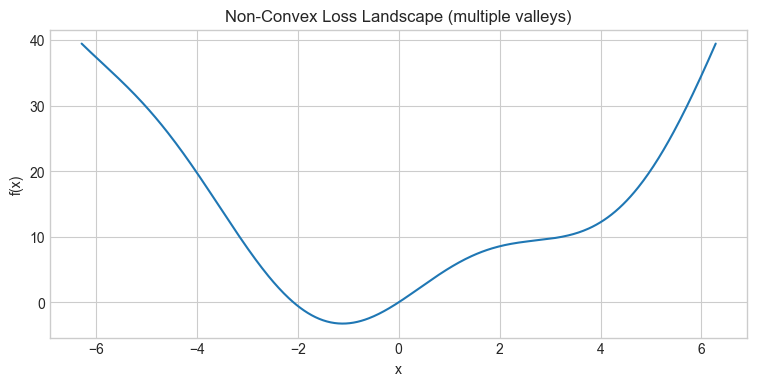

Neural network loss surfaces look more like this than a simple bowl.
SGD noise and good initialization help find useful solutions.


In [3]:
# Non-convex function: multiple local minima
x = np.linspace(-2 * np.pi, 2 * np.pi, 500)
f_nonconvex = lambda x: x ** 2 + 5 * np.sin(x)

plt.figure(figsize=(9, 4))
plt.plot(x, f_nonconvex(x))
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Non-Convex Loss Landscape (multiple valleys)")
plt.show()

print("Neural network loss surfaces look more like this than a simple bowl.")
print("SGD noise and good initialization help find useful solutions.")

---

## 11. The Jacobian and Hessian (Brief Overview)

When a function maps vectors to vectors, $\mathbf{f}: \mathbb{R}^n \to \mathbb{R}^m$, the **Jacobian** matrix contains all first-order partial derivatives:

$$\mathbf{J}_{ij} = \frac{\partial f_i}{\partial x_j}$$

The Jacobian generalizes the gradient to vector-valued functions. It appears in backpropagation when propagating gradients through layers that output vectors.

The **Hessian** matrix contains second-order partial derivatives — the derivatives of the derivatives:

$$\mathbf{H}_{ij} = \frac{\partial^2 L}{\partial w_i \partial w_j}$$

The Hessian describes the **curvature** of the loss surface. Second-order optimization methods (Newton's method, L-BFGS) use Hessian information to take smarter steps than gradient descent. In deep learning, computing the full Hessian is too expensive (billions of parameters), so first-order methods (SGD, Adam) dominate.

In [ ]:
# Hessian of L(w1, w2) = w1^2 + 2*w2^2 is constant: [[2, 0], [0, 4]]
def hessian(w1, w2):
    return np.array([[2.0, 0.0],
                     [0.0, 4.0]])

H = hessian(1, 1)
print("Hessian of L = w1² + 2w2²:")
print(H)
print("\nPositive diagonal → convex in both directions (bowl shape).")

---

## 12. Integration and Probability (Brief Connection)

**Integration** computes the area under a curve — the accumulation of a quantity. In probability and statistics (covered in later notebooks), integration is used to:

- Ensure probability density functions sum (integrate) to 1.
- Compute expected values: $E[X] = \int x \cdot p(x) \, dx$
- Normalize distributions.

The **fundamental theorem of calculus** connects differentiation and integration as inverse operations. In AI, integration appears less directly than differentiation during training, but it underpins probability theory, which is essential for generative models, Bayesian methods, and uncertainty quantification.

In [ ]:
# Numerical integration: area under f(x) = x^2 from 0 to 1 (exact answer = 1/3)
from scipy.integrate import quad

f = lambda x: x ** 2
area, _ = quad(f, 0, 1)
print(f"Integral of x² from 0 to 1: {area:.6f}")
print(f"Exact value 1/3:            {1/3:.6f}")

---

## 13. Automatic Differentiation

Computing gradients by hand for networks with millions of parameters is impossible. **Automatic differentiation** (autodiff) computes exact derivatives programmatically by tracking operations during the forward pass and applying the chain rule during a backward pass.

Two modes:
- **Forward mode:** efficient when inputs are few, outputs many.
- **Reverse mode (backpropagation):** efficient when inputs are many, output is scalar (loss) — exactly the neural network training case.

PyTorch's `tensor.backward()` and TensorFlow's `GradientTape` implement reverse-mode autodiff. You define the forward computation; the framework computes all gradients automatically.

In [ ]:
# Simple autodiff concept: computational graph
# If y = (x + 2)^2, dy/dx = 2(x + 2)

class Value:
    """Minimal scalar with forward and backward (like micrograd)."""
    def __init__(self, data, children=(), op=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(children)
        self._op = op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, n):
        out = Value(self.data ** n, (self,), f"**{n}")
        def _backward():
            self.grad += n * (self.data ** (n - 1)) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)
        build(self)
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

x = Value(3.0)
y = (x + Value(2.0)) ** Value(2.0)  # y = (x+2)^2 at x=3 → y=25
y.backward()
print(f"y = (x+2)² at x=3: y = {y.data}")
print(f"dy/dx (autodiff): {x.grad}")
print(f"dy/dx (analytical 2(x+2)): {2 * (3 + 2)}")

---

## 14. Key Formulas Reference

| Concept | Formula |
|---------|--------|
| Derivative (limit) | $f'(x) = \lim_{h\to 0} \frac{f(x+h)-f(x)}{h}$ |
| Power rule | $\frac{d}{dx}x^n = nx^{n-1}$ |
| Chain rule | $\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$ |
| Gradient | $\nabla L = [\frac{\partial L}{\partial w_1}, \ldots, \frac{\partial L}{\partial w_n}]^T$ |
| Gradient descent | $\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)$ |
| Sigmoid derivative | $\sigma'(x) = \sigma(x)(1-\sigma(x))$ |
| ReLU derivative | $1$ if $x>0$, else $0$ |
| MSE gradient | $\frac{\partial L}{\partial \hat{y}} = \hat{y} - y$ |
| Sigmoid + BCE gradient | $\hat{y} - y$ (elegant simplification) |

---

## 15. Summary

Calculus powers the training of every AI model. **Derivatives** measure how the loss changes when parameters change. The **gradient** collects all partial derivatives and points toward steepest ascent; **gradient descent** walks in the opposite direction to minimize loss. The **chain rule** enables **backpropagation** — computing gradients through composed functions layer by layer in neural networks.

Activation functions (ReLU, sigmoid, tanh, softmax) and loss functions (MSE, cross-entropy) have known derivatives that simplify training. The **learning rate** controls step size; too large or too small both cause problems. Real loss surfaces are **non-convex**, yet stochastic gradient descent finds useful solutions in practice.

**Automatic differentiation** automates the chain rule in frameworks like PyTorch, making it possible to train networks with billions of parameters. The calculus in this notebook — from the definition of a derivative to a full training loop — is the same mathematics running inside every deep learning system.